# Valley Fever Patient Grouping

Clusters synthetic Valley Fever (coccidioidomycosis) patients by symptom
presentation and social determinants of health (SDOH), evaluates whether
the resulting groups are statistically trustworthy and clinically
meaningful, and demonstrates how the grouping would actually be used in
practice.

See `README.md` in this repo for the full design write-up. This notebook
walks through the same pipeline interactively, with output kept inline.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import generate_patients
from clustering import (
    build_preprocessor, select_best_k, run_kmeans, run_agglomerative, run_gmm,
    agreement_with_kmeans, pca_2d, profile_clusters, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
)
from stability import bootstrap_stability, interpret_stability
from feature_importance import compute_feature_importance
from equity_audit import audit_categorical_association, audit_numeric_association

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)


## 1. Synthetic data

No real patient data was available, so 300 synthetic patients are generated
from three overlapping latent archetypes ("mild/well-resourced",
"moderate/under-resourced", "severe/high-risk") reflecting a documented
Valley Fever epidemiology pattern: unstable housing, weak social support,
and poor access to care associate with later, more severe presentation.
The clustering code never sees this hidden archetype label -- it's used
only afterward for internal validation.


In [ ]:
df = generate_patients(n_patients=300)
feature_df = df.drop(columns=["patient_id", "true_archetype"])
print(f"{len(df)} synthetic patients, {feature_df.shape[1]} features")
df.drop(columns=["true_archetype"]).head()


300 synthetic patients, 18 features


  patient_id  fever_severity  ...  distance_to_clinic_mi  income_bracket
0      P0001             5.1  ...                   14.6          25-50k
1      P0002             2.6  ...                    6.2            75k+
2      P0003             8.9  ...                   33.5            <25k
3      P0004             5.9  ...                   16.6          25-50k
4      P0005             2.8  ...                   13.0            75k+

[5 rows x 19 columns]

## 2. Preprocessing

Numeric/ordinal features are standardized (z-scored); nominal categoricals
(employment, education, insurance, income) are one-hot encoded rather than
label-encoded, since there's no natural numeric ordering between e.g.
"employed_ft" and "unemployed".


In [ ]:
preprocessor = build_preprocessor()
X = preprocessor.fit_transform(feature_df)
if hasattr(X, "toarray"):
    X = X.toarray()
print("Preprocessed feature matrix shape:", X.shape)


Preprocessed feature matrix shape: (300, 31)


## 3. Choosing k

Rather than hard-coding k=3 to match how the data was generated, k is
selected automatically by scanning k=2..8 and maximizing silhouette score
(inertia/elbow reported alongside as a secondary signal).


In [ ]:
best_k, k_scores = select_best_k(X, k_range=range(2, 9), model_name="kmeans")
scores_df = pd.DataFrame(k_scores)
print(f"Best k by silhouette score: {best_k}")
scores_df


Best k by silhouette score: 2


   k  silhouette  davies_bouldin  calinski_harabasz      inertia
0  2    0.358829        1.131925         218.158916  2919.893454
1  3    0.306668        1.490771         169.338831  2362.945325
2  4    0.310250        1.450845         131.581981  2167.242669
3  5    0.284089        1.681523         110.064387  2029.161891
4  6    0.116390        2.444360          91.705411  1975.874633
5  7    0.176747        2.097917          79.506345  1924.374518
6  8    0.109074        2.456930          70.356895  1882.456888

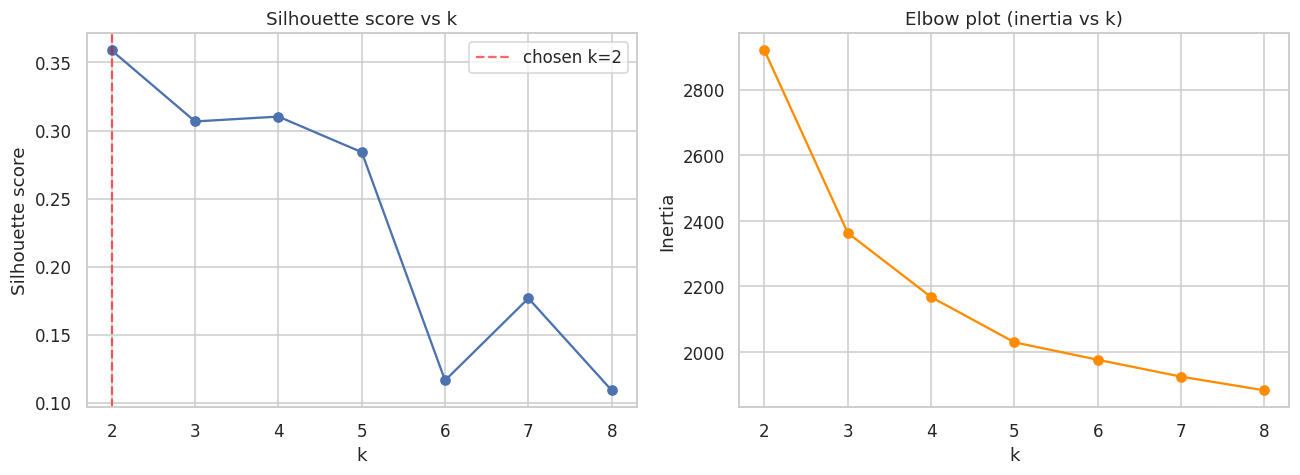

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(scores_df["k"], scores_df["silhouette"], marker="o")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"chosen k={best_k}")
axes[0].set_title("Silhouette score vs k"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Silhouette score"); axes[0].legend()
axes[1].plot(scores_df["k"], scores_df["inertia"], marker="o", color="darkorange")
axes[1].set_title("Elbow plot (inertia vs k)"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Inertia")
plt.tight_layout()
plt.show()


## 4. Clustering, cross-checked across algorithms

K-Means is the primary method (fast, deterministic, easy-to-explain
centroids). It's cross-checked against Agglomerative clustering and a
Gaussian Mixture Model -- two structurally different algorithms with no
spherical-cluster assumption. Close agreement (Adjusted Rand Index, ARI)
across all three is evidence the structure is real, not an artifact of
one algorithm's assumptions.

**Note on the GMM:** an earlier version of this notebook used
`covariance_type='full'` and had a real calibration bug -- see section 7
below for the full writeup and fix (`covariance_type='tied'`, used here).


In [ ]:
kmeans_result = run_kmeans(X, best_k)
agg_result = run_agglomerative(X, best_k)
gmm_result, gmm_probs = run_gmm(X, best_k)

ari_agg = agreement_with_kmeans(kmeans_result.labels, agg_result.labels)
ari_gmm = agreement_with_kmeans(kmeans_result.labels, gmm_result.labels)

true_labels = df["true_archetype"].astype("category").cat.codes.values
ari_vs_truth = agreement_with_kmeans(true_labels, kmeans_result.labels)

algo_comparison = pd.DataFrame([
    {"model": "KMeans", "k": kmeans_result.k, "silhouette": kmeans_result.silhouette,
     "davies_bouldin": kmeans_result.davies_bouldin, "calinski_harabasz": kmeans_result.calinski_harabasz,
     "ARI_vs_KMeans": 1.0},
    {"model": "Agglomerative", "k": agg_result.k, "silhouette": agg_result.silhouette,
     "davies_bouldin": agg_result.davies_bouldin, "calinski_harabasz": agg_result.calinski_harabasz,
     "ARI_vs_KMeans": ari_agg},
    {"model": "GaussianMixture", "k": gmm_result.k, "silhouette": gmm_result.silhouette,
     "davies_bouldin": gmm_result.davies_bouldin, "calinski_harabasz": gmm_result.calinski_harabasz,
     "ARI_vs_KMeans": ari_gmm},
])
print(f"ARI of KMeans clusters vs hidden synthetic archetype: {ari_vs_truth:.3f}")
algo_comparison


ARI of KMeans clusters vs hidden synthetic archetype: 0.728


             model  k  ...  calinski_harabasz  ARI_vs_KMeans
0           KMeans  2  ...         218.158916       1.000000
1    Agglomerative  2  ...         213.085413       0.921338
2  GaussianMixture  2  ...         215.448481       0.921337

[3 rows x 6 columns]

## 4b. Bootstrap stability

Silhouette/DB/CH scores describe a *single* clustering run, but say
nothing about whether the same groups would emerge from a slightly
different sample of patients. 50 bootstrap resamples are drawn, KMeans is
refit on each, and the resulting labels are compared to the reference
clustering via ARI. Rule of thumb: >0.75 = stable, 0.5-0.75 = moderately
stable, <0.5 = don't trust the grouping.


Bootstrap stability (k=2, 50 resamples): mean ARI=0.970 (+/-0.040) -> stable


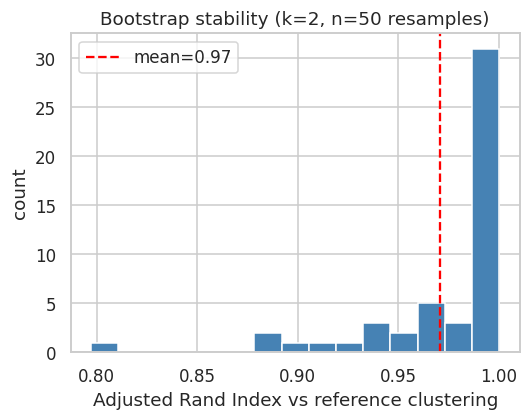

In [ ]:
stability = bootstrap_stability(X, best_k, n_boot=50)
print(f"Bootstrap stability (k={best_k}, 50 resamples): "
      f"mean ARI={stability['mean_ari']:.3f} (+/-{stability['std_ari']:.3f}) "
      f"-> {interpret_stability(stability['mean_ari'])}")

plt.figure(figsize=(5, 4))
plt.hist(stability["all_ari"], bins=15, color="steelblue", edgecolor="white")
plt.axvline(stability["mean_ari"], color="red", linestyle="--", label=f"mean={stability['mean_ari']:.2f}")
plt.title(f"Bootstrap stability (k={best_k}, n=50 resamples)")
plt.xlabel("Adjusted Rand Index vs reference clustering"); plt.ylabel("count"); plt.legend()
plt.tight_layout()
plt.show()


## 4c. What actually separates the clusters?

Clustering is unsupervised, so there's no direct notion of feature
importance. The standard workaround: train a Random Forest to predict
cluster label from the original features. Its feature importances show
what the clusters actually differ on, and cross-validated accuracy is a
sanity check that the clusters correspond to a real, learnable pattern
rather than a preprocessing artifact.


Random-forest cluster-label classifier CV accuracy: 0.980 (+/-0.007)


                        importance
weight_loss_pct           0.141186
night_sweats_severity     0.141005
access_to_care_score      0.133517
housing_stability         0.101603
joint_pain_severity       0.095235
social_support_score      0.074845
distance_to_clinic_mi     0.072333
symptom_duration_weeks    0.050300

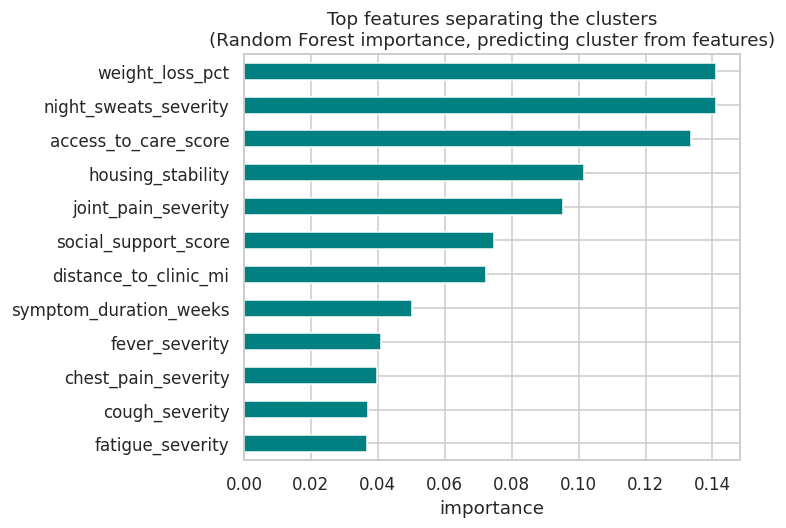

In [ ]:
importances, cv_acc = compute_feature_importance(feature_df, kmeans_result.labels, NUMERIC_FEATURES, CATEGORICAL_FEATURES)
print(f"Random-forest cluster-label classifier CV accuracy: {cv_acc.mean():.3f} (+/-{cv_acc.std():.3f})")

plt.figure(figsize=(7, 5))
importances.head(12).sort_values().plot(kind="barh", color="teal")
plt.title("Top features separating the clusters\n(Random Forest importance, predicting cluster from features)")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

importances.head(8).to_frame("importance")


## 4d. Equity audit: are the clusters just SDOH proxies?

This project deliberately includes SDOH features alongside clinical
symptoms, so it's worth explicitly checking how strongly cluster
membership associates with each SDOH variable, rather than leaving that
implicit in a heatmap. Cramer's V measures association strength for
categorical SDOH fields (0 = none, 1 = perfect); a large standardized
gap for numeric SDOH fields indicates a strong separation between
clusters on that variable.


In [ ]:
cat_audit = audit_categorical_association(feature_df, kmeans_result.labels, CATEGORICAL_FEATURES)
sdoh_numeric = ["housing_stability", "social_support_score", "access_to_care_score", "distance_to_clinic_mi"]
num_audit = audit_numeric_association(feature_df, kmeans_result.labels, sdoh_numeric)
print("Categorical SDOH association with cluster membership:")
display_cat = cat_audit
display_cat


Categorical SDOH association with cluster membership:


             feature  cramers_v       p_value  mutual_info
3     income_bracket      0.590  1.637577e-22        0.196
0  employment_status      0.586  2.198095e-21        0.185
2   insurance_status      0.519  1.990000e-17        0.145
1    education_level      0.408  8.573878e-11        0.088

In [ ]:
print("Numeric SDOH standardized gap between clusters:")
num_audit


Numeric SDOH standardized gap between clusters:


                 feature  max_standardized_gap_between_clusters
2   access_to_care_score                                   1.60
0      housing_stability                                   1.57
1   social_support_score                                   1.49
3  distance_to_clinic_mi                                   1.40

**Reading this:** cluster membership turns out to be strongly associated
with income bracket, employment status, and insurance status (Cramer's V
in the 0.5-0.6 range). That means this "elevated risk" cluster is
arguably as much a *resource-access* group as a *clinical severity*
group -- worth flagging explicitly rather than only presenting the
clinical story, since it changes how the grouping should (and shouldn't)
be used in a real deployment. See README section 3 for the full
discussion.


## 5. Visualizing the clusters (PCA)

PCA to 2 components is used purely for visualization -- clustering itself
is always performed in the full standardized feature space.


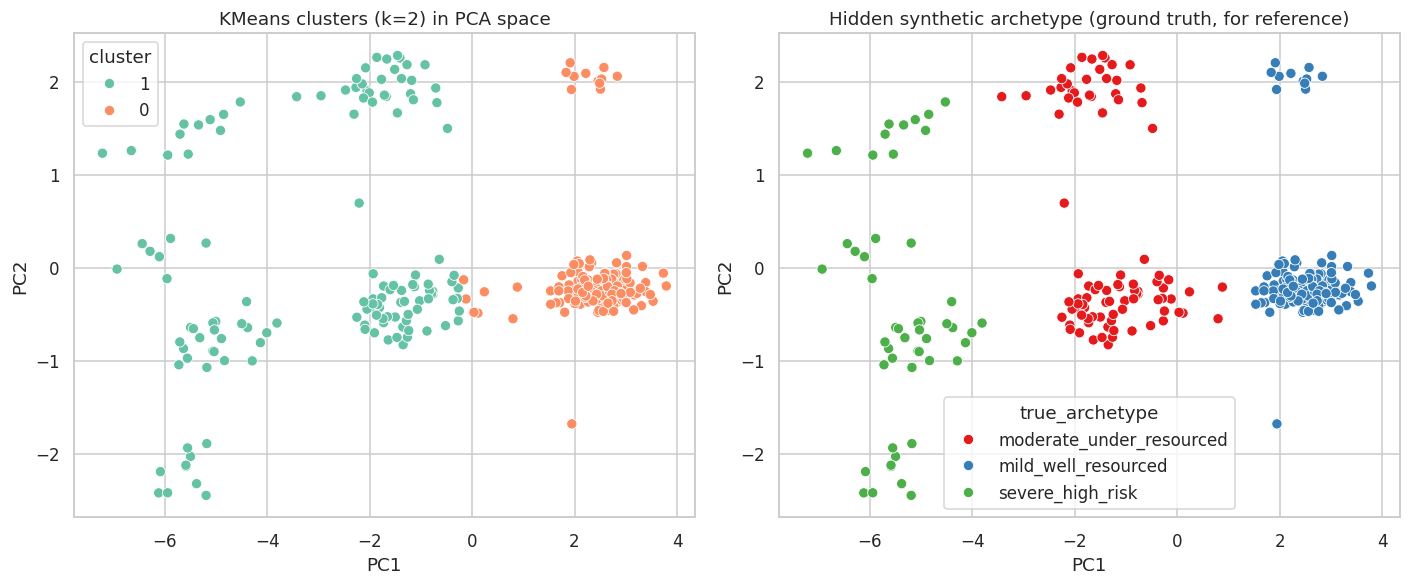

In [ ]:
coords = pca_2d(X)
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["cluster"] = kmeans_result.labels.astype(str)
plot_df["true_archetype"] = df["true_archetype"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="Set2", ax=axes[0], s=45)
axes[0].set_title(f"KMeans clusters (k={best_k}) in PCA space")
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="true_archetype", palette="Set1", ax=axes[1], s=45)
axes[1].set_title("Hidden synthetic archetype (ground truth, for reference)")
plt.tight_layout()
plt.show()


## 6. Cluster profiles

Plain-language per-cluster summaries: mean of numeric features, mode of
categorical features, and cluster size.


In [ ]:
profile = profile_clusters(feature_df, kmeans_result.labels)
profile


         n_patients  fever_severity  ...  insurance_status_mode  income_bracket_mode
cluster                              ...                                            
0               162            2.98  ...                private                 75k+
1               138            6.34  ...               medicaid                 <25k

[2 rows x 19 columns]

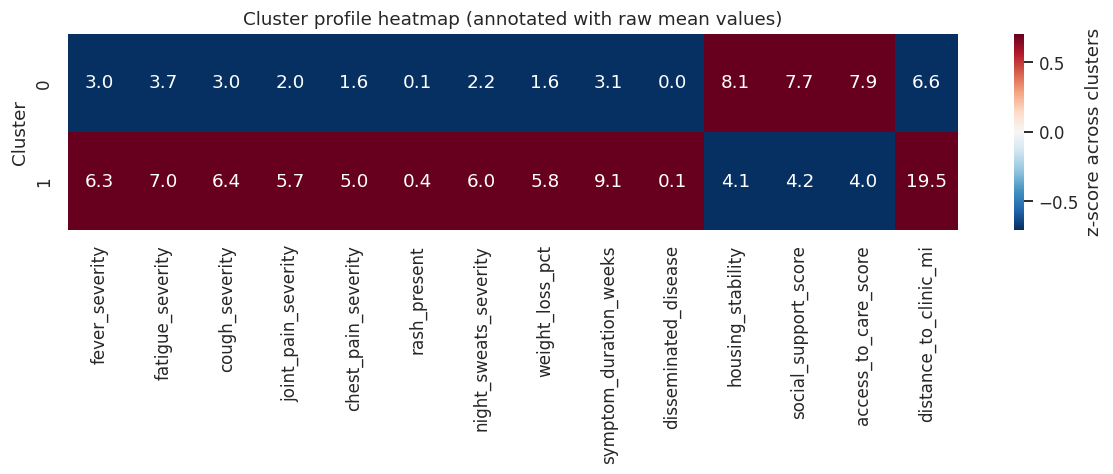

In [ ]:
z_profile = (profile[NUMERIC_FEATURES] - profile[NUMERIC_FEATURES].mean()) / profile[NUMERIC_FEATURES].std()
plt.figure(figsize=(11, 4.5))
sns.heatmap(z_profile, annot=profile[NUMERIC_FEATURES].values, fmt=".1f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score across clusters"})
plt.title("Cluster profile heatmap (annotated with raw mean values)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


## 7. A calibration bug I caught and fixed

The first version of the GMM used `covariance_type='full'` (a separate
covariance matrix per cluster). Testing it on a point constructed to sit
**exactly halfway** between the two cluster centroids exposed the
problem: it should score close to 50/50, but `full` covariance reported
~100% confidence. With ~30 dimensions after one-hot encoding and only
~150 patients per cluster, per-component covariance estimation is
underdetermined -- even ~99.7% of the *training* points were scored above
99% confidence, which isn't plausible for real overlapping clinical data.

The cell below reproduces both the bug and the fix side by side.


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
centroid_midpoint = ((km.cluster_centers_[0] + km.cluster_centers_[1]) / 2).reshape(1, -1)

for cov_type in ["full", "tied"]:
    gmm_test = GaussianMixture(n_components=2, random_state=42, n_init=5, covariance_type=cov_type, reg_covar=1e-3).fit(X)
    probs = gmm_test.predict_proba(centroid_midpoint)[0]
    print(f"covariance_type={cov_type!r:8s} -> midpoint probabilities: {np.round(probs, 3)}"
          f"  {'BUG: should be ~50/50' if probs.max() > 0.9 else '(correctly ambiguous)'}")


covariance_type='full'   -> midpoint probabilities: [0. 1.]  BUG: should be ~50/50
covariance_type='tied'   -> midpoint probabilities: [0.558 0.442]  (correctly ambiguous)


`covariance_type='tied'` (one covariance matrix shared across
components -- effectively a linear-discriminant-style boundary) is used
throughout the rest of this project as a result.


## 8. From batch analysis to something usable

The rest of this notebook clusters a static, historical dataset -- useful
for understanding the population, but not directly usable by a case
worker with one new patient in front of them. `assign_new_patient.py`
fits the preprocessor + KMeans + (properly calibrated) GMM once on the
historical population and scores new patients one at a time, reporting a
**boundary-case flag**: if the top cluster probability is below 0.65, the
tool recommends routing to a human case manager instead of auto-applying
a group care pathway.


In [ ]:
from assign_new_patient import fit_and_save_model, assign_patient, EXAMPLE_NEW_PATIENT
import joblib

preprocessor_p, kmeans_model_p, gmm_model_p, feature_df_p, labels_p = fit_and_save_model(k=best_k)
gmm_to_kmeans = joblib.load("outputs/model/gmm_to_kmeans_label_map.joblib")

print("Example new patient (clear-cut, high clinical/social risk):")
result = assign_patient(EXAMPLE_NEW_PATIENT, preprocessor_p, kmeans_model_p, gmm_model_p, gmm_to_kmeans)
for k_, v_ in result.items():
    print(f"  {k_}: {v_}")


Example new patient (clear-cut, high clinical/social risk):
  kmeans_cluster: 1
  gmm_cluster_probabilities: {'cluster_0': 0.0, 'cluster_1': 1.0}
  confidence: 1.0
  boundary_case_flag: False
  recommendation: Reasonably confident match to cluster 1 -- apply that group's care pathway.


In [ ]:
# Sanity check: the exact geometric midpoint between the two cluster
# centroids should be a genuine boundary case, and should trigger the flag.
c0, c1 = kmeans_model_p.cluster_centers_
midpoint = ((c0 + c1) / 2).reshape(1, -1)
hard_cluster = int(kmeans_model_p.predict(midpoint)[0])
raw_probs = gmm_model_p.predict_proba(midpoint)[0]
aligned = np.zeros(len(raw_probs))
for gmm_label, kmeans_label in gmm_to_kmeans.items():
    aligned[kmeans_label] = raw_probs[gmm_label]

print("Centroid-midpoint patient:")
print(f"  kmeans_cluster: {hard_cluster}")
print(f"  gmm_cluster_probabilities: {dict(enumerate(np.round(aligned, 3)))}")
print(f"  boundary_case_flag: {aligned.max() < 0.65}")


Centroid-midpoint patient:
  kmeans_cluster: 0
  gmm_cluster_probabilities: {0: np.float64(0.558), 1: np.float64(0.442)}
  boundary_case_flag: True


## 9. If I were extending this for a real deployment

- Replace synthetic data with real, de-identified, IRB-approved patient
  data; re-run k-selection and algorithm-agreement checks since real data
  will have messier, non-Gaussian structure.
- Handle missing data explicitly -- real SDOH survey data is often
  incomplete, and this pipeline currently assumes complete records.
- Validate clusters against downstream outcomes (hospitalization,
  time-to-treatment) if available.
- For Arizona specifically, Valley Fever is a reportable disease --
  county/state notifiable-disease surveillance data (Arizona Department
  of Health Services) would be the natural real clinical source, and CDC
  PLACES or the Area Deprivation Index could supplement or cross-validate
  self-reported SDOH fields.
- Consider a mixed-type distance measure (e.g., Gower distance) or
  k-prototypes as an alternative to one-hot + K-Means for high-
  cardinality categorical features.
- Run the equity audit on real data and bring the results to a domain
  expert / ethics review *before* any resource-allocation use, not after.
- Build a lightweight interface around `assign_new_patient.py` (rather
  than a notebook or CLI) so case workers can score patients without
  touching code.
